# Analysis Of BaseLine Network

In [ ]:
import numpy as np
import pandas as pd
import os
import random

import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pickle
import matplotlib.pyplot as plt




In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#CONFIG FOR MY BASE PROJECT-----------------
config = {"device" : device,"learning_rate" :0.001,"epochs" : 50, "label_smoothing":0.05}
#-------------------------------------------

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything()

print(f"Using device: {device}")


Using device: cuda


In [ ]:
from torchvision import datasets, transforms

# Separate explicit endpoints for the original splits
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform = [transforms.ToTensor()])
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform = [transforms.ToTensor()])
# --- ADDED LINES ---
# Extracting and scaling the training features and labels
x_train = train_dataset.data.float() / 255.0
y_train = train_dataset.targets
x_test = test_dataset.data.float()/255.0
y_test = test_dataset.targets

# --- ADDED LINES FOR FLATTENING ---
# Flatten from [60000, 28, 28] to [60000, 784]
x_train = x_train.view(x_train.size(0), -1)
x_test  = x_test.view(x_test.size(0), -1)




100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.81MB/s]


OneHot encoding the Ydata

In [ ]:
'''technically, we do not need to onehot encode our ydata as the loss function
CrossEntropyLoss accepts target lables encoded in class form AND onehot encoded
form. I am choosing to OneHotEncode because we may want to perform label
smoothing or other transforms later on.'''

y_train = F.one_hot(y_train, num_classes=10)
y_test  = F.one_hot(y_test, num_classes=10)


Defining and Loading a dataloader class

In [ ]:
from torch.utils.data.dataloader import DataLoader
# making a torch.Dataset object that we will need to feed into DataLoader
class data_loader(torch.utils.data.Dataset):
  def __init__(self, x_tensor, y_tensor):
    self.x= x_tensor
    self.y= y_tensor

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]



In [ ]:
def get_dataloader(x_train,y_train,x_test,y_test):
  '''
  this function returns the high level train_loader, test_loader and val_loader
  objects
  it takes in the preprocessed train, test data in the form of tensors.
  '''
  train_data= data_loader(x_train, y_train)
  test_data = data_loader(x_test, y_test)

  train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
  test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
  return train_loader, test_loader

Defining the label smoother function

In [ ]:
def label_smoothing(labels, epsilon=0.1):
  '''
  we are essentially going to augment the batch_targets into smooth targets.
  '''
  num_classes = labels.size(1)
  smoothed_labels = (1.0 - epsilon) * labels + (epsilon / num_classes)
  return smoothed_labels

 BASELINE NEURAL NETWORK CLASS

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
class neural_net(nn.Module):
  def __init__(self, num_of_features, num_of_output_classes):
    super().__init__()


    self.fc1 = nn.Linear(784, 16)
    self.left_fc1 = nn.Linear(16, 8)
    self.left_fc2 = nn.Linear(8, 8)

    self.right_fc1 = nn.Linear(16, 12)
    self.right_fc2 = nn.Linear(12, 8)
    self.penultimate_output_collector = nn.Identity() # Explicit layer to capture penultimate activations
    self.output_layer = nn.Linear(16, 10)

  def forward(self,x):
    x = F.relu(self.fc1(x))
    xleft = F.relu(self.left_fc1(x))
    xleft2 = F.relu(self.left_fc2(xleft))
    xleft = xleft + xleft2
    xright = F.relu(self.right_fc1(x))
    xright = F.relu(self.right_fc2(xright))

    combination = torch.cat((xleft, xright), dim=1)
    penultimate_activations = self.penultimate_output_collector(combination) # Pass through the new layer
    out = self.output_layer(penultimate_activations)
    return out

In [ ]:
def build_model(model_type, config):
  '''
  creates an instance of given model class blueprint and moves it to the device.
  '''
  model = model_type(784, 10)
  model.to(config["device"])

  return model

notice how the neural network has no changes for cases with or without label smooting. Label smoothing is simply a regualrization technique used to aumgment our target data in order to allow for less overconfidence of our model.

plotting loss vs epoch

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
  '''
  returns the metrics coming from this epoch. returns train_metrics(dict):
  {train_loss:, train_accuracy:}

  '''
  model.train()
  # sets the evaluation parameters to zero first
  total_epoch_loss = 0
  training_correct = 0
  training_total = 0
  for batch_features, batch_labels in train_loader:
    # Move batch_features and batch_labels to the correct device
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    optimizer.zero_grad()
    outputs= model(batch_features)
    loss= criterion(outputs, batch_labels.float())
    total_epoch_loss += loss.item()
    loss.backward()
    optimizer.step()
    _, predicted =torch.max(outputs, 1)
    training_correct+=(predicted==torch.argmax(batch_labels, 1)).sum().item()
    training_total += batch_labels.shape[0]
  average_loss= total_epoch_loss/len(train_loader)
  training_metrics = {'train_loss': average_loss, 'train_accuracy': training_correct/training_total}
  return training_metrics

In [ ]:
def test_one_epoch(model, test_loader, device, nbins =20):
  model.eval()
  total =0
  bin_total = torch.zeros(nbins, device = device)
  bin_aggregate = torch.zeros(nbins, device= device)
  correct = torch.zeros(nbins, device = device)
  average = torch.zeros(nbins, device = device)
  bin_edges = torch.linspace(0, 1, nbins + 1).to(device)
  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      output= model(batch_features)
      probabilities = torch.softmax(output, dim=1)
      confidence, predicted =torch.max(probabilities, 1)

      is_correct = (predicted == torch.argmax(batch_labels, 1))

      bin_indices = torch.bucketize(confidence, bin_edges[1:-1])

      for b in range(nbins):
        mask = (bin_indices == b)
        bin_aggregate[b] += confidence[mask].sum()
 #       average[b] = average[b]*0.9 + confidence[mask].mean() * 0.1
        bin_total[b] += mask.sum()
        correct[b] += is_correct[mask].sum()
      # Convert one-hot encoded batch_labels to class indices for comparison
      total += batch_labels.shape[0]

  emperical = torch.zeros(nbins, device = device)
  for b in range(nbins):
    emperical[b] = correct[b]/bin_total[b]

  average = bin_aggregate.div(bin_total)
  non_empty = bin_total> 0
  average = average[non_empty]
  emperical = emperical[non_empty]
  bin_total = bin_total[non_empty]
  ece = ((bin_total)/bin_total.sum()*(average - emperical).abs()).sum()
  accuracy= correct.sum()/total
  return accuracy, ece



In [ ]:
def run_model(model, config, train_loader, test_loader):
  model = build_model(model, config)
  lossfn = nn.CrossEntropyLoss(label_smoothing= config["label_smoothing"])
  optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
  history = {"training_loss": [], "validation_accuracy" : [], "training_accuracy":[], "ece":[]}
  training_epoch_losses = []
  validation_accuracy =[]
  training_accuracy = []

  for epoch in range(config["epochs"]):
    epoch_metrics = train_one_epoch(model, train_loader, lossfn, optimizer, device)
    history["training_loss"].append(epoch_metrics['train_loss'])
    history["training_accuracy"].append(epoch_metrics['train_accuracy'])
    accuracy, ece = test_one_epoch(model, test_loader, device)
    history["validation_accuracy"].append(accuracy)
    history["ece"].append(ece)
  return history, model

In [ ]:
def display_metrics(metrics):
    epochs = range(1, len(metrics["training_loss"]) + 1)

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Training metrics", fontsize=13, fontweight="medium")

    # loss
    ax_loss.plot(epochs, metrics["training_loss"], label="train loss")
    ax_loss.set(title="Loss", xlabel="epoch", ylabel="loss")
    ax_loss.legend()

    # accuracy
    ax_acc.plot(epochs, metrics["training_accuracy"], label="train acc")
    ax_acc.plot(epochs, metrics["validation_accuracy"],   label="val acc", linestyle="--")
    ax_acc.set(title="Accuracy", xlabel="epoch", ylabel="accuracy", ylim=(0, 1))
    ax_acc.legend()


    plt.tight_layout()
    plt.show()


# MAIN EXPERIMENTATION DATA:

In [ ]:
def extract_penultimate_layer_activations(model, test_loader, device):
  global penultimate_layer_representations
  labels = []
  model.eval()

  # Attach the hook to the new penultimate_output_collector layer
  hook_handle = model.penultimate_output_collector.register_forward_hook(forward_hook)
  with torch.no_grad():
    for i, (images, targets) in enumerate(test_loader):
      images = images.to(device)
      _ = model(images)
      # The forward_hook (global) populates the global `penultimate_layer_representations`.
      labels.append(targets.numpy())

  hook_handle.remove()
  final_reps = np.concatenate(penultimate_layer_representations)
  final_labels = np.concatenate(labels)

  return final_reps, final_labels

In [ ]:
def forward_hook(module, input, output):
  global penultimate_layer_representations
  penultimate_layer_representations.append(input[0].detach().cpu().numpy())

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Apply t-SNE
def plot_tsne(activations, labels):
  reduced = TSNE(n_components=2, random_state = 42).fit_transform(activations)

  plt.figure(figsize=(8,6))
  # Convert one-hot encoded labels to class indices for coloring
  class_labels = np.argmax(labels, axis=1)
  # Explicitly define vmin and vmax to guide matplotlib in colormapping
  scatter = plt.scatter(reduced[:,0],reduced[:,1], c=class_labels, cmap="tab10", s=10, alpha= 0.7, vmin=0, vmax=9)
  plt.colorbar(scatter)
  plt.title("t-SNE of the penultimate layer activations")
  plt.show()

to successfully run our experiment, we analyse the following things:
1. compare the tsne of smoothed vs unsmoothed data at different smoothing values
2. compare the validation accuracy and loss across different smoothing parameters
3. compare the Expected Calibration error for different smoothing parameters
4. provide a better, more dynamic form of smoothing based on similarity between classes (semantic class smoothing)

[tensor(0.7883, device='cuda:0'), tensor(0.8278, device='cuda:0'), tensor(0.8329, device='cuda:0'), tensor(0.8390, device='cuda:0'), tensor(0.8441, device='cuda:0'), tensor(0.8416, device='cuda:0'), tensor(0.8463, device='cuda:0'), tensor(0.8476, device='cuda:0'), tensor(0.8486, device='cuda:0'), tensor(0.8471, device='cuda:0'), tensor(0.8506, device='cuda:0'), tensor(0.8560, device='cuda:0'), tensor(0.8546, device='cuda:0'), tensor(0.8593, device='cuda:0'), tensor(0.8537, device='cuda:0'), tensor(0.8593, device='cuda:0'), tensor(0.8590, device='cuda:0'), tensor(0.8599, device='cuda:0'), tensor(0.8588, device='cuda:0'), tensor(0.8597, device='cuda:0'), tensor(0.8592, device='cuda:0'), tensor(0.8546, device='cuda:0'), tensor(0.8614, device='cuda:0'), tensor(0.8522, device='cuda:0'), tensor(0.8558, device='cuda:0'), tensor(0.8615, device='cuda:0'), tensor(0.8569, device='cuda:0'), tensor(0.8616, device='cuda:0'), tensor(0.8616, device='cuda:0'), tensor(0.8610, device='cuda:0'), tensor(0.

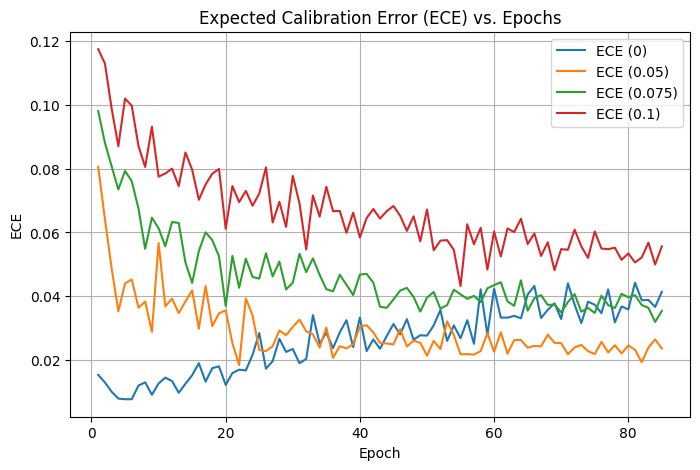

In [ ]:
def show_ece_differences(label_smoothing_list):
  train_loader, test_loader = get_dataloader(x_train, y_train, x_test, y_test)
  plt.figure(figsize=(8, 5))
  config["epochs"] = 85
  for label_smoothing in label_smoothing_list:
    config["label_smoothing"] = label_smoothing
    metrics, model = run_model(neural_net, config, train_loader= train_loader, test_loader= test_loader)
    print(metrics["validation_accuracy"], " is the accuracy for the ", label_smoothing, " label smoothing")
    epochs = range(1, len(metrics["training_loss"]) + 1)
    ece = [e.cpu().item() for e in metrics["ece"]]
    plt.plot(epochs, ece, label=f"ECE ({label_smoothing})")
  plt.title("Expected Calibration Error (ECE) vs. Epochs")
  plt.xlabel("Epoch")
  plt.ylabel("ECE")
  plt.legend()
  plt.grid(True)
  plt.show()

show_ece_differences([0,0.05,0.075,0.1])


In [ ]:
penultimate_layer_representations = []

<Figure size 800x500 with 0 Axes>

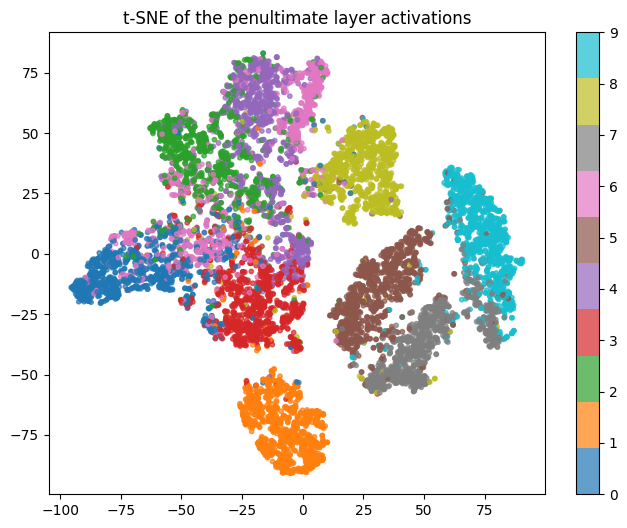

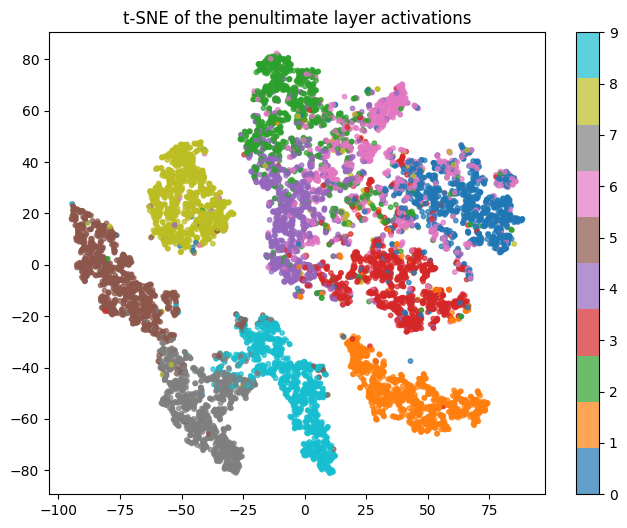

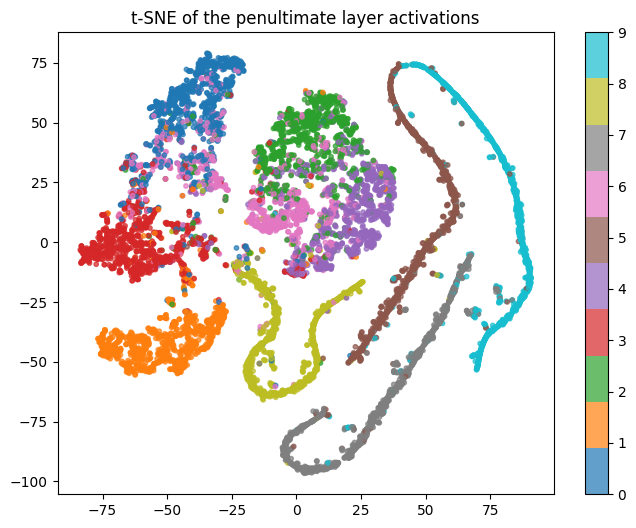

In [ ]:
def show_tsne(label_smoothing_list):
  train_loader, test_loader = get_dataloader(x_train, y_train, x_test, y_test)
  plt.figure(figsize=(8, 5))
  config["epochs"] = 85
  for label_smoothing in label_smoothing_list:
    global penultimate_layer_representations
    penultimate_layer_representations = []
    config["label_smoothing"] = label_smoothing
    metrics, model = run_model(neural_net, config, train_loader= train_loader, test_loader= test_loader)
    rep, labels = extract_penultimate_layer_activations(model, test_loader, device)
    plot_tsne(rep,labels)

show_tsne([0,0.1, 0.5])

the 4th point, about better alternative to label smoothing is a semantic label smoothing, which involves dynamically soft smoothing hard targets based on a similarity matrix(or confusion matrix).
I will implement this after task 1.